# LLM Model인 Bert Model을 사용하기 위해서 가능하면 GPU 서버로 진행
> T4 GPU로 변경

# [영화 평가 데이터](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data)
- 이 파일에는 Full MovieLens 데이터셋에 등록된 45,000편의 영화에 대한 메타데이터가 포함되어 있습니다.
- 이 데이터셋은 2017년 7월 이전에 개봉한 영화로 구성되어 있습니다. 데이터 포인트에는 출연진, 제작진, 줄거리 키워드, 예산, 수익, 포스터, 개봉일, 언어, 제작사, 국가, TMDB 투표 수 및 투표 평균 등이 포함됩니다.
- 이 데이터세트에는 45,000편의 영화에 대해 27만 명의 사용자가 작성한 2,600만 건의 평점이 포함된 파일도 포함되어 있습니다.
- 평점은 1점부터 5점까지의 점수로 매겨지며, GroupLens 공식 웹사이트에서 수집되었습니다.

## 데이터(파일) 설명

- movies_metadata.csv
  - 주요 영화 메타데이터 파일입니다.
  - Full MovieLens 데이터세트에 포함된 45,000편의 영화에 대한 정보가 포함되어 있습니다.
  - 포스터, 배경, 예산, 수익, 개봉일, 언어, 제작 국가 및 제작사 등의 정보가 포함됩니다.
- keywords.csv
  - MovieLens 영화의 줄거리 키워드를 담고 있습니다.
  - 문자열화된 JSON 객체 형태로 제공됩니다.
- links_small.csv
  - 전체 데이터 세트의 9,000개 영화 중 작은 하위 세트의 TMDB 및 IMDB ID를 포함합니다.

# 데이터

In [4]:
import pandas as pd
from ast import literal_eval

## 데이터 로드

### movies_metadata

> movies_metadata는 영화에 대한 메타데이터(제목, 장르 등)이다.

In [ ]:
movies_metadata = pd.read_csv('movies_metadata.csv')

movies_metadata.shape

In [6]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

### links_small

> links_small.csv를 이용하여 movies_metadata의 데이터 수를 줄이자   
> 너무 데이터가 많으면, 전처리 및 추천할 때, 시간이 오래 걸리거나 메모리가 부족한 경우가 발생할 수 있다.

In [ ]:
links_small = pd.read_csv('links_small.csv')

links_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


In [8]:
# 결측치 제거 및 데이터 형변환
links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')
links_small.shape

(9112,)

In [9]:
# links_small에 포함된 id만 사용
movies_metadata_small = movies_metadata[movies_metadata['id'].isin(links_small.astype('str'))]
movies_metadata_small.shape

(9099, 24)

### movies_keywords

In [10]:
movies_keywords = pd.read_csv(DATA_PATH+'keywords.csv')

movies_keywords.columns

Index(['id', 'keywords'], dtype='object')

In [11]:
movies_metadata_small['id'] = movies_metadata_small['id'].astype('str')
movies_keywords['id'] = movies_keywords['id'].astype('str')

# 영화 아이디(id)를 기준으로 데이터를 합치기
movies_metadata_small = movies_metadata_small.merge(movies_keywords, on=['id'])

# 결과 확인
movies_metadata_small.shape

/tmp/ipython-input-11-1618596873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_metadata_small['id'] = movies_metadata_small['id'].astype('str')


(9151, 25)

> 추천에 필요한 컬럼만 사용하기   
> title(영화 제목), genres(영화 장르), overview(영화 요약), popularity(영화 인기도), release_date(영화 개볼일)

In [12]:
columns = ['title', 'genres', 'keywords', 'overview', 'popularity', 'release_date']

movies = movies_metadata_small[columns]
movies.head()

,title,genres,keywords,overview,popularity,release_date
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",When siblings Judy and Peter discover an encha...,17.015539,1995-12-15
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392...",A family wedding reignites the ancient feud be...,11.7129,1995-12-22
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",Just when George Banks has recovered from his ...,8.387519,1995-02-10


## 데이터 전처리

### 장르(genres) 전처리

In [13]:
movies['str_genres'] = movies['genres'].fillna('[]')\
                    .apply(literal_eval)\
                    .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])\
                    .apply(lambda x: ", ".join(x) if len(x) > 0 else None)

movies[['str_genres', 'genres']].head()

/tmp/ipython-input-13-270039552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['str_genres'] = movies['genres'].fillna('[]')\


,str_genres,genres
0,"Animation, Comedy, Family","[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,"Adventure, Family, Fantasy","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,"Comedy, Romance","[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,"Comedy, Drama, Romance","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,Comedy,"[{'id': 35, 'name': 'Comedy'}]"


### 키워드(keywords) 전처리

In [14]:
movies['str_keywords'] = movies['keywords'].fillna('[]')\
                    .apply(literal_eval)\
                    .apply(lambda x: sorted([i['name'] for i in x]) if isinstance(x, list) else [])\
                    .apply(lambda x: ", ".join(x) if len(x) > 0 else None)

movies[['str_keywords', 'keywords']].head()

/tmp/ipython-input-14-3922486139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['str_keywords'] = movies['keywords'].fillna('[]')\


,str_keywords,keywords
0,"boy, boy next door, friends, friendship, jealo...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,"based on children's book, board game, disappea...","[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,"best friend, duringcreditsstinger, fishing, ol...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,"based on novel, chick flick, divorce, interrac...","[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,"aging, baby, confidence, contraception, daught...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


### 장르 + 키워드 + 영화 요약

In [15]:
def get_genres_keywords_overview(row):
  return f"""
  genres:
  {row['str_genres']}

  keywords:
  {row['str_keywords']}

  overview:
  {row['overview']}
  """

In [16]:
movies['genres_keywords_overview'] = movies.apply(get_genres_keywords_overview, axis=1)

movies[['genres_keywords_overview','str_genres', 'str_keywords', 'overview']].head()

/tmp/ipython-input-16-243275937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['genres_keywords_overview'] = movies.apply(get_genres_keywords_overview, axis=1)


,genres_keywords_overview,str_genres,str_keywords,overview
0,"\n genres:\n Animation, Comedy, Family\n\n ...","Animation, Comedy, Family","boy, boy next door, friends, friendship, jealo...","Led by Woody, Andy's toys live happily in his ..."
1,"\n genres:\n Adventure, Family, Fantasy\n\n ...","Adventure, Family, Fantasy","based on children's book, board game, disappea...",When siblings Judy and Peter discover an encha...
2,"\n genres:\n Comedy, Romance\n\n keywords:\...","Comedy, Romance","best friend, duringcreditsstinger, fishing, ol...",A family wedding reignites the ancient feud be...
3,"\n genres:\n Comedy, Drama, Romance\n\n key...","Comedy, Drama, Romance","based on novel, chick flick, divorce, interrac...","Cheated on, mistreated and stepped on, the wom..."
4,"\n genres:\n Comedy\n\n keywords:\n aging,...",Comedy,"aging, baby, confidence, contraception, daught...",Just when George Banks has recovered from his ...


In [17]:
movies[['genres_keywords_overview']].loc[0].values[0]

"\n  genres:\n  Animation, Comedy, Family\n\n  keywords:\n  boy, boy next door, friends, friendship, jealousy, new toy, rivalry, toy, toy comes to life\n\n  overview:\n  Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.\n  "

### 개봉일(release_date) 전처리
> release_date의 문자열 데이터를 날짜 데이터로 형변환    
> 날짜 데이터로 변환하게 되면, 년/월/일 등의 데이터를 추출하기 쉬워진다.

In [18]:
# release_date의 데이터 타입이 문자열(object)임을 확인할 수 있다.
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9151 entries, 0 to 9150
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   title                     9151 non-null   object
 1   genres                    9151 non-null   object
 2   keywords                  9151 non-null   object
 3   overview                  9139 non-null   object
 4   popularity                9151 non-null   object
 5   release_date              9151 non-null   object
 6   str_genres                9116 non-null   object
 7   str_keywords              8380 non-null   object
 8   genres_keywords_overview  9151 non-null   object
dtypes: object(9)
memory usage: 643.6+ KB


> errors='coerce'를 입력하면, 변환할 수 있는 데이터는 수치형으로 변환되고 변환할 수 없는 데이터는 NaN으로 처리됩니다.   
> NaN은 Not a Number의 약자입니다.

In [19]:
# 문자열(object)를 날짜(datetime64)로 데이터 형변환
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# 결과 확인
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9151 entries, 0 to 9150
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   title                     9151 non-null   object        
 1   genres                    9151 non-null   object        
 2   keywords                  9151 non-null   object        
 3   overview                  9139 non-null   object        
 4   popularity                9151 non-null   object        
 5   release_date              9151 non-null   datetime64[ns]
 6   str_genres                9116 non-null   object        
 7   str_keywords              8380 non-null   object        
 8   genres_keywords_overview  9151 non-null   object        
dtypes: datetime64[ns](1), object(8)
memory usage: 643.6+ KB


/tmp/ipython-input-19-1583773313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')


> release_date를 이용하여 year(년도)를 추출하자   
> 추천을 할때 가능하면 최신 년도를 추천하자

In [20]:
movies['year'] = movies['release_date'].dt.year

movies[['release_date', 'year']].head()

/tmp/ipython-input-20-3364271264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['year'] = movies['release_date'].dt.year


,release_date,year
0,1995-10-30,1995
1,1995-12-15,1995
2,1995-12-22,1995
3,1995-12-22,1995
4,1995-02-10,1995


### 영화 인기도(popularity)

In [21]:
# 문자열을 실수값으로 변경
movies['popularity'] = movies['popularity'].astype(float)

/tmp/ipython-input-21-976940292.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['popularity'] = movies['popularity'].astype(float)


In [22]:
import numpy as np

# 문자열을 실수값으로 변경
movies['popularity_log'] = np.log(movies['popularity'])

# log를 이용해서 왜도 해결
movies[['popularity_log', 'popularity']].describe()

/tmp/ipython-input-22-49007243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['popularity_log'] = np.log(movies['popularity'])


,popularity_log,popularity
count,9151.000000,9151.000000
mean,1.559346,7.259378
std,1.159141,9.353553
min,-12.429216,0.000004
25%,1.077271,2.936654
50%,1.858137,6.411782
75%,2.287990,9.855113
max,6.305341,547.488298


<Axes: xlabel='popularity_log', ylabel='Count'>

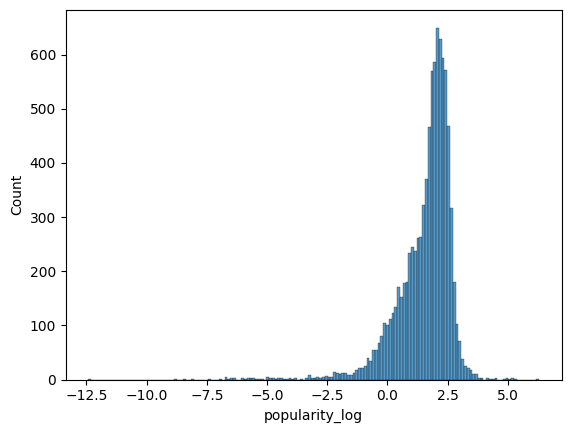

In [23]:
import seaborn as sns

sns.histplot(movies['popularity_log'])

## 데이터 결측치 제거

> 각 컬럼별 결측치 비율 확인

```python
# movies.isnull().sum() -> 컬럼별 결측치의 합
# movies.shape[0] -> 전체 데이터의 수
# (movies.isnull().sum() / movies.shape[0])
# -> 각 컬럼별 결측치의 비율
(movies.isnull().sum() / movies.shape[0])\
  # 소수점 4자리까지만 표현
  .round(4)\
  # 가장 높은 비율(결측치) 순으로 정렬
  .sort_values(ascending=False)

```

In [24]:
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (9151, 11)


,0
str_keywords,0.0843
str_genres,0.0038
overview,0.0013
keywords,0.0000
genres,0.0000
title,0.0000
popularity,0.0000
release_date,0.0000
genres_keywords_overview,0.0000
year,0.0000


> 결측치 데이터 제거하기

In [25]:
# 결측치 데이터 제거
movies = movies.dropna()
# 인덱스 재정의
movies = movies.reset_index(drop=True)

# 확인
print(f"movies.shape: {movies.shape}")
(movies.isnull().sum() / movies.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (8368, 11)


,0
title,0.0
genres,0.0
keywords,0.0
overview,0.0
popularity,0.0
release_date,0.0
str_genres,0.0
str_keywords,0.0
genres_keywords_overview,0.0
year,0.0


# LLM 기반 Contents Based Filtering

## Embedding
- Embedding은 단어, 문장, 이미지 등과 같은 복잡한 데이터를 숫자 벡터로 바꿔주는 방식입니다.
- 이 벡터는 원본 데이터의 의미나 특징을 가능한 한 잘 유지하면서 AI가 이해하고 계산할 수 있도록 해줍니다.

Bert Model을 이용해서 Embedding을 하면, 기존에 배웠단 `단어간의 빈도 수가 아닌` 아래 이미지와 같이 `토큰(단어)간의 관계성`에 대한 벡터화를 진행할 수 있습니다.

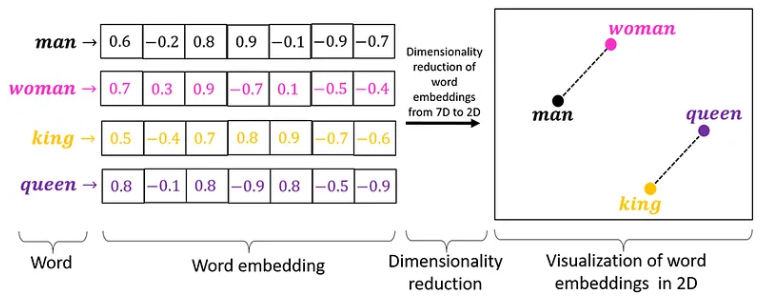

## BERT LLM (Large Language Model, 거대 언어 모델)
- BERT(Bidirectional Encoder Representations from Transformers)는 2018년 Google이 발표한 대표적인 LLM(대형 언어 모델) 중 하나입니다.
- BERT의 대표 활용 예
  - 질문 응답 시스템 (예: "Where was Obama born?" → "Hawaii")
  - 문장 분류 (예: 긍정/부정 판단)
  - `문장 유사도 측정`
  - 검색엔진 개선 (Google 검색도 BERT 사용 중)

### Bert Model을 이용한 유사도 측정
1. Bert Model을 이용해서 각 문장을 백터로 변환
  -  변환된 백터 데이터는 단어간의 의미가 반영된 정보임
2. 해당 백터 데이터를 코사인 유사도를 이용하여 유사도값을 계산

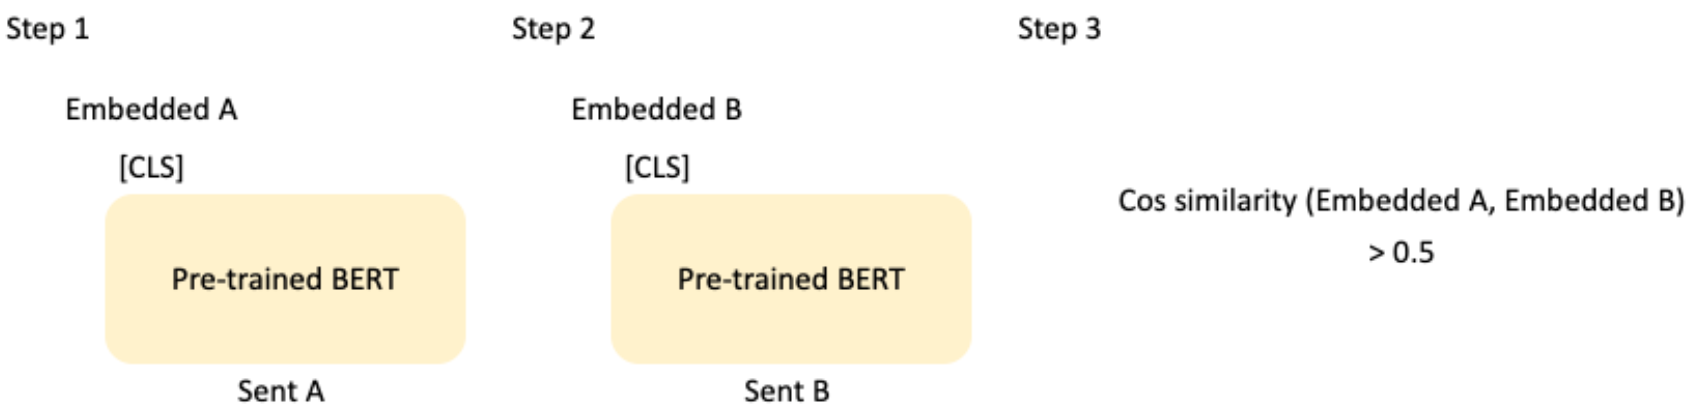

In [26]:
from transformers import BertTokenizer, BertModel
import torch

model_name = "bert-base-uncased"

### GPU 사용 유무

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Tokenizer

> Tokenizer는 인간의 언어(문장, 단어)를 모델이 이해할 수 있는 단위인 "토큰(token)"으로 쪼개주는 도구입니다.

In [28]:
tokenizer = BertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

#### 토크나이즈 예제

1. 문장을 토큰으로 분할

In [29]:
# 입력 문장 정의
sentence = "Transformers are amazing!"

# 토크나이즈 (토큰 분할)
tokens = tokenizer.tokenize(sentence)
tokens

['transformers', 'are', 'amazing', '!']

2. 토큰을 index로 변환

In [30]:
# 토큰을 id(index)로 변환
token_ids = tokenizer.convert_tokens_to_ids(tokens)
token_ids

[19081, 2024, 6429, 999]

3. Bert Model 인풋 데이터로 변환

- `return_tensors='pt'`는 PyTorch 텐서 형태로 반환하도록 설정한 것입니다.

| 항목               | 의미                      | 예시 값                     |
| ---------------- | ----------------------- | ------------------------ |
| `input_ids`      | 문장의 토큰 ID 시퀀스           | `[101, 19081, ..., 102]` |
| `token_type_ids` | 문장 구분 (0: 문장1, 1: 문장2)  | `[0, 0, 0, 0, 0, 0]`     |
| `attention_mask` | 토큰 처리 여부 (1: 처리, 0: 무시) | `[1, 1, 1, 1, 1, 1]`     |


In [31]:
# 전체 인코딩 (토큰 + 스페셜 토큰 + 패딩 등 자동 처리)
encoded = tokenizer(sentence, return_tensors='pt')
encoded

{'input_ids': tensor([[  101, 19081,  2024,  6429,   999,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

4. 인풋 데이터 중 특수 토큰의 의미 확인

- `101`과 `102`는 `[CLS]`, `[SEP]` 토큰 (BERT 전용 특수 토큰)입니다.
  - [CLS](Classification token): 항상 문장의 맨 앞에 추가됩니다.
  - [SEP](Separator token): 단일 문장일 때는 문장 끝에 하나 붙이고, 두 문장 입력할 때는 두 문장 사이를 나누는 데 사용됩니다.

In [32]:
input_ids = encoded['input_ids'][0]
input_ids

tensor([  101, 19081,  2024,  6429,   999,   102])

5. 인풋 데이터를 다시 문자 데이터로 변환

In [33]:
# 디코딩 (숫자 → 텍스트)
decoded_sentence = tokenizer.decode(input_ids)
decoded_sentence

'[CLS] transformers are amazing! [SEP]'

### Bert Model

In [34]:
model = BertModel.from_pretrained(model_name).to(device)
model.eval() # 예측모드

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

### BERT Embedding

In [35]:
def get_bert_embedding(text):
    # text를 토큰화 처리
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)

    # BERT를 이용하여 벡터화(예측)
    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.last_hidden_state는 (batch_size(배치), sequence_length(토큰), hidden_size(벡터))와 같은 3차원 데이터이다.
    # -> 이 마지막 차원(last_hidden_state)이 hidden_size의 데이터가 우리가 원하는 임베딩 결과 데이터이다.
    # BERT는 입력 문장 앞에 항상 [CLS] 토큰을 붙이고, 이 토큰의 출력은 문장 전체를 대표하도록 학습합니다.
    # -> 따라서 [CLS] 토큰의 출력값을 사용
    # -> [CLS]는 문장의 맨앞에 위치하기 때문에 [:, 0, :]을 이용해서 추출 가능
    return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

In [36]:
# tqdm -> 진행바 표시
from tqdm import tqdm

# tqdm을 Pandas apply에 통합
tqdm.pandas()

# overview를 Bert Embedding 진행
movies['embedding'] = movies['genres_keywords_overview'].progress_apply(get_bert_embedding)

100%|██████████| 8368/8368 [01:37<00:00, 86.13it/s] 


In [37]:
movies[['embedding', 'genres_keywords_overview']].head()

,embedding,genres_keywords_overview
0,"[-0.5323146, -0.1825819, -0.0439798, -0.268421...","\n genres:\n Animation, Comedy, Family\n\n ..."
1,"[-0.47834966, -0.40722114, 0.040653564, -0.106...","\n genres:\n Adventure, Family, Fantasy\n\n ..."
2,"[-0.18983027, -0.2576074, 0.06928462, -0.10150...","\n genres:\n Comedy, Romance\n\n keywords:\..."
3,"[-0.22428201, -0.22372206, 0.30354795, -0.3271...","\n genres:\n Comedy, Drama, Romance\n\n key..."
4,"[-0.28747866, -0.36115006, 0.19042781, -0.1224...","\n genres:\n Comedy\n\n keywords:\n aging,..."


### Cosine Similarity

In [38]:
all_embeddings = movies['embedding'].values.tolist()

In [39]:
import numpy as np

# python list를 numpy array로 변환
all_embeddings = np.array(all_embeddings)

# shape -> (전체 데이터 수, BERT Embedding 크기)
all_embeddings.shape

(8368, 768)

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_of_overview = cosine_similarity(all_embeddings, all_embeddings)

# shape -> (전체 데이터 수, 전체 데이터 수)
similarity_of_overview.shape

(8368, 8368)

In [41]:
# 유사도 데이터를 index 데이터로 변환 및 정렬 작업
sorted_similarity_of_overview = similarity_of_overview.argsort()[:, ::-1]

## 추천하기

In [42]:
def recommendation(title_name, top_k=5):
  # 기준 영화 추출
  movie_of_title = movies[movies['title'] == title_name]
  print(f"{title_name}의 장르: {movie_of_title['str_genres'].values[0]}")

  # 기준 영화 인덱스
  movie_index_of_title = movie_of_title.index.values[0]

  # 기준 영화를 기준으로 가장 유사도가 높은 영화들의 인덱스 추출
  similar_indexes = sorted_similarity_of_overview[movie_index_of_title, :(top_k*2)]
  # 메트릭스(2차원의 데이터)를 벡터(1차원의 데이터)로 변환
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes != movie_index_of_title]

  # 유사도 기반으로 추출된 영화 추천
  return movies.iloc[similar_indexes].sort_values(by=['popularity_log','year'], ascending=False)[:top_k]

In [43]:
recommendation_movies = recommendation('Robin Hood')

recommendation_movies[['title', 'popularity_log', 'year', 'str_genres', 'str_keywords', 'overview']]

Robin Hood의 장르: Animation, Family


,title,popularity_log,year,str_genres,str_keywords,overview
5944,Pirates of the Caribbean: Dead Man's Chest,3.382874,2006,"Action, Adventure, Fantasy","aftercreditsstinger, bondage, captain, card ga...",Captain Jack Sparrow works his way out of a bl...
871,Raiders of the Lost Ark,2.990799,1981,"Action, Adventure","archaeologist, archeology , ark of the covenan...",When Dr. Indiana Jones – the tweed-suited prof...
8324,The Huntsman: Winter's War,2.848403,2016,"Action, Adventure, Drama","fairy tale, huntsman, magic, snow white, witch",As two evil sisters prepare to conquer the lan...
6835,Sherlock Holmes,2.752771,2009,"Action, Adventure, Crime, Mystery","arrest, black magic, clue, coffin, detective, ...","Eccentric consulting detective, Sherlock Holme..."
1488,The Great Mouse Detective,2.414477,1986,"Animation, Comedy, Family","cartoon mouse, detective, london england, quee...",When the diabolical Professor Ratigan kidnaps ...
